In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [98]:
single_df = pd.read_csv("../output/AD-47.csv")
single_df.head()

,Date,Timestamp,R,D,Margin,Daily Margin Change,Vote Difference,Total Votes Cast,Total Unprocessed Ballots*,Jurisdiction,Unprocessed Ballots
0,2024-11-06,08:10:00,76366,77665,0.008433,NaN,1299,154031,NaN,Riverside,NaN
1,2024-11-06,17:25:00,79882,80590,0.004412,-0.004021,708,160472,NaN,Riverside,NaN
2,2024-11-07,17:37:00,82601,83241,0.003859,-0.000553,640,165842,609450.0,Riverside,350000.0
3,2024-11-08,17:12:00,82601,83241,0.003859,0.000000,640,165842,586630.0,Riverside,350000.0
4,2024-11-09,17:44:00,90634,90917,0.001559,-0.002300,283,181551,461630.0,Riverside,225000.0


In [99]:
df = pd.read_csv("../output/combined_races.csv")
df

,Date,Timestamp,R,D,Margin,Daily Margin Change,Vote Difference,Total Votes Cast,Total Unprocessed Ballots*,Jurisdiction,Unprocessed Ballots,Race
0,2024-11-05,23:46:00,113246,94852,0.088391,NaN,18394,208098,NaN,Alpine,NaN,CD-3
1,2024-11-06,08:10:00,148102,109302,0.150736,0.062345,38800,257404,NaN,Alpine,NaN,CD-3
2,2024-11-06,17:25:00,148131,109327,0.150720,-0.000016,38804,257458,NaN,Alpine,NaN,CD-3
3,2024-11-07,17:37:00,148639,110087,0.149007,-0.001713,38552,258726,523355.0,Alpine,32.0,CD-3
4,2024-11-08,17:12:00,170208,130087,0.133605,-0.015402,40121,300295,391011.0,Alpine,32.0,CD-3
...,...,...,...,...,...,...,...,...,...,...,...,...
1286,2024-11-29,18:55:00,117147,113272,0.016817,0.000000,3875,230419,11565.0,San Diego,0.0,AD-74
1287,2024-12-02,18:09:00,117157,113280,0.016825,0.000007,3877,230437,11238.0,San Diego,0.0,AD-74
1288,2024-12-03,23:53:00,117208,113338,0.016786,-0.000038,3870,230546,0.0,San Diego,0.0,AD-74
1289,2024-12-04,20:15:00,117208,113338,0.016786,0.000000,3870,230546,0.0,San Diego,0.0,AD-74


In [100]:
len(df['Jurisdiction'].unique())

25

In [101]:
df[df["Race"] == "AD-74"]["Date"].min()

'2024-11-14'

In [102]:
df.groupby(["Race", "Jurisdiction"])["Date"].min().unstack("Jurisdiction").max(axis=1)

Race
AD-47    2024-11-06
AD-58    2024-11-05
AD-74    2024-11-14
CD-13    2024-11-05
CD-21    2024-11-06
CD-22    2024-11-05
CD-27    2024-11-05
CD-3     2024-11-05
CD-40    2024-11-05
CD-41    2024-11-05
CD-45    2024-11-05
CD-47    2024-11-05
CD-49    2024-11-05
CD-9     2024-11-05
SD-19    2024-11-05
SD-37    2024-11-06
SD-5     2024-11-06
dtype: str

In [103]:
df.groupby(["Race", "Jurisdiction"])["Date"].count().unstack("Jurisdiction").max(axis=1)

Race
AD-47    28.0
AD-58    30.0
AD-74    18.0
CD-13    31.0
CD-21    29.0
CD-22    30.0
CD-27    30.0
CD-3     30.0
CD-40    30.0
CD-41    30.0
CD-45    30.0
CD-47    30.0
CD-49    30.0
CD-9     30.0
SD-19    30.0
SD-37    28.0
SD-5     29.0
dtype: float64

--- Election Results & Flips ---
Race: AD-47 | Final Winner: R
  -> FLIP DETECTED: Flipped to R on 2024-11-11 17:07 (E+6.7)
Race: AD-58 | Final Winner: R
  -> FLIP DETECTED: Flipped to R on 2024-11-06 08:10 (E+1.3)
Race: AD-74 | Final Winner: R
Race: CD-13 | Final Winner: D
  -> FLIP DETECTED: Flipped to R on 2024-11-06 08:10 (E+1.3)
  -> FLIP DETECTED: Flipped to D on 2024-11-26 17:05 (E+21.7)
Race: CD-21 | Final Winner: D
Race: CD-22 | Final Winner: R
Race: CD-27 | Final Winner: D
  -> FLIP DETECTED: Flipped to D on 2024-11-09 17:44 (E+4.7)
Race: CD-3 | Final Winner: R
Race: CD-40 | Final Winner: R
Race: CD-41 | Final Winner: R
  -> FLIP DETECTED: Flipped to R on 2024-11-06 08:10 (E+1.3)
Race: CD-45 | Final Winner: D
  -> FLIP DETECTED: Flipped to D on 2024-11-16 17:52 (E+11.7)
Race: CD-47 | Final Winner: D
  -> FLIP DETECTED: Flipped to R on 2024-11-06 08:10 (E+1.3)
  -> FLIP DETECTED: Flipped to D on 2024-11-08 17:12 (E+3.7)
Race: CD-49 | Final Winner: D
Race: CD-9 | Final Winner: 

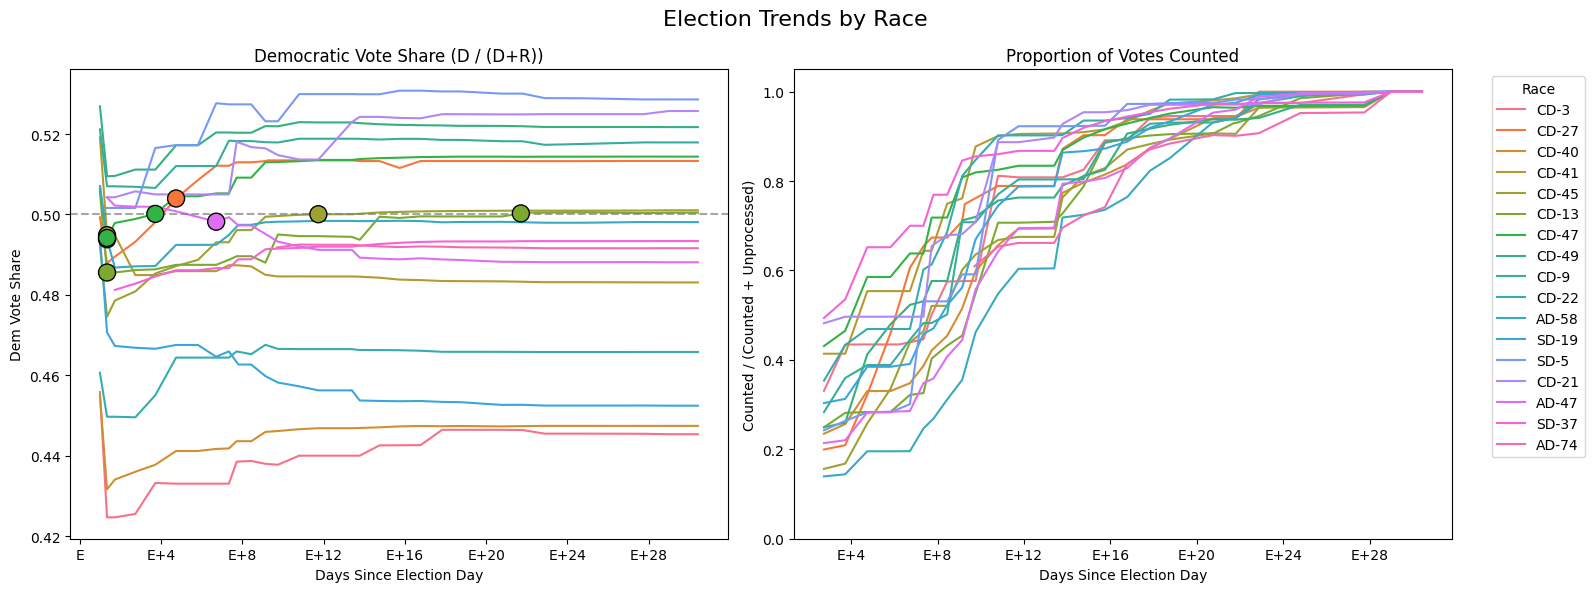

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator

# Copy df to avoid modifying the original
race_df = df.copy()

# --- NEW: Combine Date and Timestamp into a single complete Datetime ---
# This joins '2024-11-06' and '14:30:00' into '2024-11-06 14:30:00'
race_df['Datetime'] = pd.to_datetime(race_df['Date'].astype(str) + ' ' + race_df['Timestamp'].astype(str))

# Now drop duplicates and sort using the complete Datetime
race_df = race_df.drop_duplicates(subset=['Race', 'Datetime'])
race_df = race_df.sort_values('Datetime')

# Calculate EXACT Fractional Days Since Election using the new Datetime column
election_day = pd.to_datetime('2024-11-05')
race_df['Exact_Days_Since_Election'] = (race_df['Datetime'] - election_day).dt.total_seconds() / 86400.0

# Ensure relevant columns are numeric
cols_to_numeric = ['D', 'R', 'Total Votes Cast', 'Total Unprocessed Ballots*']
for col in cols_to_numeric:
    if col in race_df.columns:
        race_df[col] = pd.to_numeric(race_df[col].astype(str).str.replace(',', ''), errors='coerce')
        
# Calculate metrics
race_df['Dem_Vote_Share'] = race_df['D'] / (race_df['D'] + race_df['R'])
race_df['Prop_Votes_Received'] = race_df['Total Votes Cast'] / (race_df['Total Votes Cast'] + race_df['Total Unprocessed Ballots*'])

# Track Flip Coordinates for Plotting
flip_points = []
unique_races = race_df['Race'].unique() 

print("--- Election Results & Flips ---")
for race, group in race_df.groupby('Race'):
    group = group.sort_values('Datetime').reset_index(drop=True)
    
    if len(group) == 0:
        continue
        
    last_drop = group.iloc[-1]
    final_winner = 'D' if last_drop['Dem_Vote_Share'] > 0.5 else ('R' if last_drop['Dem_Vote_Share'] < 0.5 else 'Tie')
    
    print(f"Race: {race} | Final Winner: {final_winner}")
    
    current_leader = 'D' if group.iloc[0]['Dem_Vote_Share'] > 0.5 else ('R' if group.iloc[0]['Dem_Vote_Share'] < 0.5 else 'Tie')
    
    for i in range(1, len(group)):
        row = group.iloc[i]
        day_leader = 'D' if row['Dem_Vote_Share'] > 0.5 else ('R' if row['Dem_Vote_Share'] < 0.5 else 'Tie')
        
        if day_leader != 'Tie' and day_leader != current_leader:
            days_e = row['Exact_Days_Since_Election']
            e_str = f"E+{days_e:.1f}" if days_e > 0 else (f"E{days_e:.1f}" if days_e < 0 else "E")
            time_str = row['Datetime'].strftime('%Y-%m-%d %H:%M')
            
            print(f"  -> FLIP DETECTED: Flipped to {day_leader} on {time_str} ({e_str})")
            
            # Save the coordinates of the flip for the scatterplot
            flip_points.append({
                'Race': race,
                'Exact_Days_Since_Election': days_e,
                'Dem_Vote_Share': row['Dem_Vote_Share']
            })
            
            current_leader = day_leader
            
print("--------------------------------\n")

# Custom axis formatter function for "E+i"
def e_plus_formatter(x, pos):
    val = round(x)
    if val > 0:
        return f"E+{val}"
    elif val < 0:
        return f"E{val}" 
    else:
        return "E"

formatter = FuncFormatter(e_plus_formatter)

# Create a single figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Election Trends by Race', fontsize=16)

# 1. Democratic Vote Share
sns.lineplot(data=race_df, x='Exact_Days_Since_Election', y='Dem_Vote_Share', hue='Race', hue_order=unique_races, ax=axes[0])

# Overlay Flip Dots
if flip_points:
    flip_df = pd.DataFrame(flip_points)
    sns.scatterplot(
        data=flip_df, 
        x='Exact_Days_Since_Election', 
        y='Dem_Vote_Share', 
        hue='Race', 
        hue_order=unique_races, 
        ax=axes[0], 
        s=150,                  
        edgecolor='black',      
        zorder=5,               
        legend=False            
    )

axes[0].set_title('Democratic Vote Share (D / (D+R))')
axes[0].set_ylabel('Dem Vote Share')
axes[0].set_xlabel('Days Since Election Day')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7)
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].xaxis.set_major_formatter(formatter)
axes[0].get_legend().remove()

# 2. Proportion of Votes Received
sns.lineplot(data=race_df, x='Exact_Days_Since_Election', y='Prop_Votes_Received', hue='Race', hue_order=unique_races, ax=axes[1])
axes[1].set_title('Proportion of Votes Counted')
axes[1].set_ylabel('Counted / (Counted + Unprocessed)')
axes[1].set_xlabel('Days Since Election Day')
axes[1].set_ylim(0, 1.05)
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].xaxis.set_major_formatter(formatter)
axes[1].legend(title='Race', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

--- Election Results & Flips ---
Race: AD-47 | Final Winner: R
  -> FLIP DETECTED: Flipped to R on 2024-11-11 (E+6)
Race: AD-58 | Final Winner: R
  -> FLIP DETECTED: Flipped to R on 2024-11-06 (E+1)
Race: AD-74 | Final Winner: R
Race: CD-13 | Final Winner: D
  -> FLIP DETECTED: Flipped to R on 2024-11-06 (E+1)
  -> FLIP DETECTED: Flipped to D on 2024-11-26 (E+21)
Race: CD-21 | Final Winner: D
Race: CD-22 | Final Winner: R
Race: CD-27 | Final Winner: D
  -> FLIP DETECTED: Flipped to D on 2024-11-09 (E+4)
Race: CD-3 | Final Winner: R
Race: CD-40 | Final Winner: R
Race: CD-41 | Final Winner: R
  -> FLIP DETECTED: Flipped to R on 2024-11-06 (E+1)
Race: CD-45 | Final Winner: D
  -> FLIP DETECTED: Flipped to D on 2024-11-16 (E+11)
Race: CD-47 | Final Winner: D
  -> FLIP DETECTED: Flipped to R on 2024-11-06 (E+1)
  -> FLIP DETECTED: Flipped to D on 2024-11-08 (E+3)
Race: CD-49 | Final Winner: D
Race: CD-9 | Final Winner: D
Race: SD-19 | Final Winner: R
Race: SD-37 | Final Winner: R
Race: SD-5

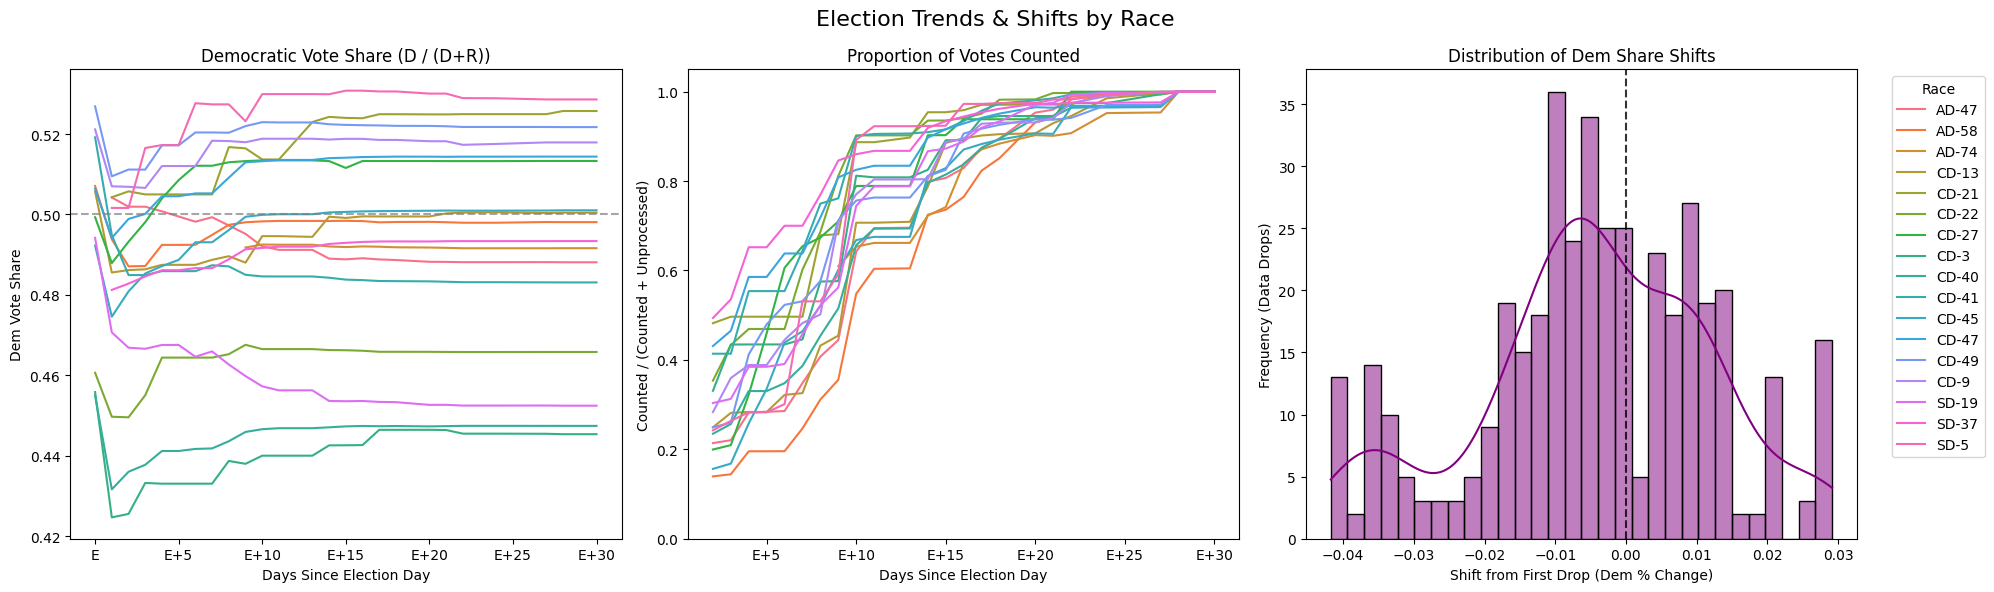

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Ensure df is defined before this step
race_df = df.drop_duplicates(subset=['Race', 'Date']).copy()

# Ensure Date is datetime and sort chronologically
race_df['Date'] = pd.to_datetime(race_df['Date'])
race_df = race_df.sort_values(['Race', 'Date'])

# Calculate Days Since Election
election_day = pd.to_datetime('2024-11-05')
race_df['Days_Since_Election'] = (race_df['Date'] - election_day).dt.days

# Ensure relevant columns are numeric
cols_to_numeric = ['D', 'R', 'Total Votes Cast', 'Total Unprocessed Ballots*']
for col in cols_to_numeric:
    if col in race_df.columns:
        race_df[col] = pd.to_numeric(race_df[col].astype(str).str.replace(',', ''), errors='coerce')
        
# Calculate metrics
race_df['Dem_Vote_Share'] = race_df['D'] / (race_df['D'] + race_df['R'])
race_df['Prop_Votes_Received'] = race_df['Total Votes Cast'] / (race_df['Total Votes Cast'] + race_df['Total Unprocessed Ballots*'])

# --- NEW: Calculate Difference from First Drop ---
# Grab the very first Dem_Vote_Share for each race and assign it to a new column
race_df['First_Drop_Dem_Share'] = race_df.groupby('Race')['Dem_Vote_Share'].transform('first')

# Calculate the shift: Positive means Dem gained, Negative means Dem lost ground
race_df['Dem_Share_Diff'] = race_df['Dem_Vote_Share'] - race_df['First_Drop_Dem_Share']

# Filter out the first drop to isolate "the rest of the data"
first_dates = race_df.groupby('Race')['Date'].transform('min')
rest_of_data = race_df[race_df['Date'] > first_dates]

# --- Print Winners and Exact Flip Days ---
print("--- Election Results & Flips ---")
for race, group in race_df.groupby('Race'):
    group = group.sort_values('Date').reset_index(drop=True)
    if len(group) == 0:
        continue
        
    last_drop = group.iloc[-1]
    final_winner = 'D' if last_drop['Dem_Vote_Share'] > 0.5 else ('R' if last_drop['Dem_Vote_Share'] < 0.5 else 'Tie')
    
    print(f"Race: {race} | Final Winner: {final_winner}")
    
    current_leader = 'D' if group.iloc[0]['Dem_Vote_Share'] > 0.5 else ('R' if group.iloc[0]['Dem_Vote_Share'] < 0.5 else 'Tie')
    
    for i in range(1, len(group)):
        row = group.iloc[i]
        day_leader = 'D' if row['Dem_Vote_Share'] > 0.5 else ('R' if row['Dem_Vote_Share'] < 0.5 else 'Tie')
        
        if day_leader != 'Tie' and day_leader != current_leader:
            days_e = row['Days_Since_Election']
            e_str = f"E+{int(days_e)}" if days_e > 0 else (f"E{int(days_e)}" if days_e < 0 else "E")
            date_str = row['Date'].strftime('%Y-%m-%d')
            
            print(f"  -> FLIP DETECTED: Flipped to {day_leader} on {date_str} ({e_str})")
            current_leader = day_leader
print("--------------------------------\n")


# Custom axis formatter function for "E+i"
def e_plus_formatter(x, pos):
    if x > 0:
        return f"E+{int(x)}"
    elif x < 0:
        return f"E{int(x)}" 
    else:
        return "E"

formatter = FuncFormatter(e_plus_formatter)

# --- PLOTTING ---
# Create a figure with 3 subplots now (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Election Trends & Shifts by Race', fontsize=16)

# 1. Democratic Vote Share
sns.lineplot(data=race_df, x='Days_Since_Election', y='Dem_Vote_Share', hue='Race', ax=axes[0])
axes[0].set_title('Democratic Vote Share (D / (D+R))')
axes[0].set_ylabel('Dem Vote Share')
axes[0].set_xlabel('Days Since Election Day')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7) 
axes[0].xaxis.set_major_formatter(formatter)
axes[0].get_legend().remove()

# 2. Proportion of Votes Received
sns.lineplot(data=race_df, x='Days_Since_Election', y='Prop_Votes_Received', hue='Race', ax=axes[1])
axes[1].set_title('Proportion of Votes Counted')
axes[1].set_ylabel('Counted / (Counted + Unprocessed)')
axes[1].set_xlabel('Days Since Election Day')
axes[1].set_ylim(0, 1.05) 
axes[1].xaxis.set_major_formatter(formatter)
axes[1].get_legend().remove() # Move legend to the final plot to save space

# 3. NEW: Histogram of Shifts
sns.histplot(data=rest_of_data, x='Dem_Share_Diff', bins=30, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Distribution of Dem Share Shifts')
axes[2].set_xlabel('Shift from First Drop (Dem % Change)')
axes[2].set_ylabel('Frequency (Data Drops)')
axes[2].axvline(0, color='black', linestyle='--', alpha=0.8, label='No Change (0)')

# Add the main legend to the far right plot
handles, labels = axes[1].get_legend_handles_labels()
axes[2].legend(handles=handles, labels=labels, title='Race', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

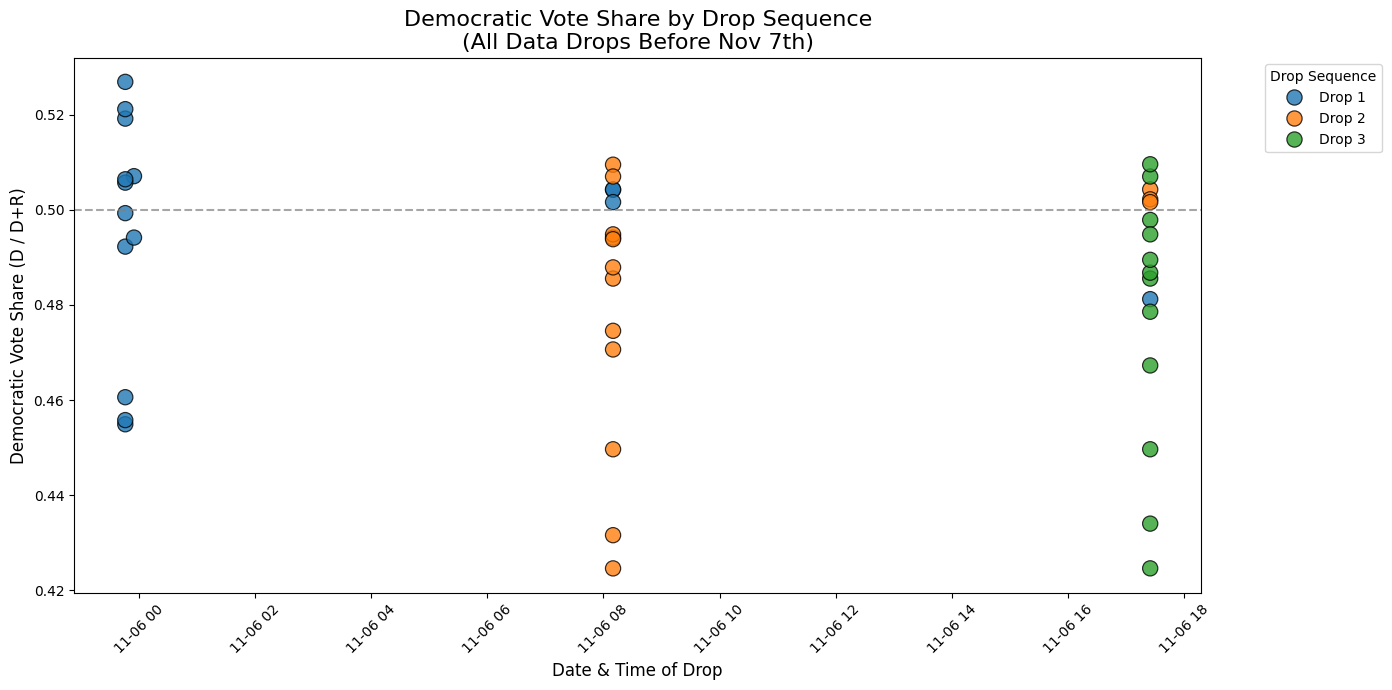

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copy df to avoid modifying the original
plot_df = df.copy()

# Create the complete Datetime column
plot_df['Datetime'] = pd.to_datetime(plot_df['Date'].astype(str) + ' ' + plot_df['Timestamp'].astype(str))
plot_df = plot_df.drop_duplicates(subset=['Race', 'Datetime'])

# Ensure D and R are numeric to calculate vote share
for col in ['D', 'R']:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col].astype(str).str.replace(',', ''), errors='coerce')
        
# Calculate the Democratic vote share
plot_df['Dem_Vote_Share'] = plot_df['D'] / (plot_df['D'] + plot_df['R'])

# --- NEW: Calculate the Drop Number for each race ---
# Sort chronologically so the numbering matches the exact time sequence
plot_df = plot_df.sort_values(['Race', 'Datetime'])

# Group by race and count upwards. cumcount() starts at 0, so we add 1.
plot_df['Drop_Sequence'] = plot_df.groupby('Race').cumcount() + 1

# Convert into a clean string label for the legend (e.g., "Drop 1", "Drop 2")
plot_df['Drop_Number'] = 'Drop ' + plot_df['Drop_Sequence'].astype(str)

# --- NEW: Filter for all drops before Nov 7th ---
plot_df = plot_df[plot_df['Datetime'] < pd.to_datetime('2024-11-07')]

# Sort the dataframe by the sequence integer before plotting 
# This ensures the legend renders in the correct order (Drop 1, Drop 2, Drop 3...)
plot_df = plot_df.sort_values('Drop_Sequence')

# Create the Scatter Plot
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=plot_df, 
    x='Datetime', 
    y='Dem_Vote_Share', 
    hue='Drop_Number',         
    palette='tab10',    # A clean color palette with highly distinct categorical colors
    s=120,              
    edgecolor='black',  
    alpha=0.8
)

plt.title("Democratic Vote Share by Drop Sequence\n(All Data Drops Before Nov 7th)", fontsize=16)
plt.xlabel("Date & Time of Drop", fontsize=12)
plt.ylabel("Democratic Vote Share (D / D+R)", fontsize=12)

# Add a horizontal dashed line at 50% to show who is leading
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Format the x-axis dates so they are legible
plt.xticks(rotation=45)

# Move the legend outside the plot to prevent it from covering data points
plt.legend(title='Drop Sequence', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [110]:
condensed_df = df.drop(["Jurisdiction", "Unprocessed Ballots"], axis=1, errors='ignore')
condensed_df = condensed_df.drop_duplicates()
condensed_df

,Date,Timestamp,R,D,Margin,Daily Margin Change,Vote Difference,Total Votes Cast,Total Unprocessed Ballots*,Race
0,2024-11-05,23:46:00,113246,94852,0.088391,NaN,18394,208098,NaN,CD-3
1,2024-11-06,08:10:00,148102,109302,0.150736,0.062345,38800,257404,NaN,CD-3
2,2024-11-06,17:25:00,148131,109327,0.150720,-0.000016,38804,257458,NaN,CD-3
3,2024-11-07,17:37:00,148639,110087,0.149007,-0.001713,38552,258726,523355.0,CD-3
4,2024-11-08,17:12:00,170208,130087,0.133605,-0.015402,40121,300295,391011.0,CD-3
...,...,...,...,...,...,...,...,...,...,...
1268,2024-11-29,18:55:00,117147,113272,0.016817,0.000000,3875,230419,11565.0,AD-74
1269,2024-12-02,18:09:00,117157,113280,0.016825,0.000007,3877,230437,11238.0,AD-74
1270,2024-12-03,23:53:00,117208,113338,0.016786,-0.000038,3870,230546,0.0,AD-74
1271,2024-12-04,20:15:00,117208,113338,0.016786,0.000000,3870,230546,0.0,AD-74


In [119]:
# Combine, convert to datetime, floor to the hour, and group all in one step
hourly_datetime = pd.to_datetime(condensed_df['Date'].astype(str) + ' ' + condensed_df['Timestamp'].astype(str)).dt.floor('h')

condensed_df.groupby(hourly_datetime)["Race"].count()

2024-11-05 23:00:00    12
2024-11-06 08:00:00    15
2024-11-06 17:00:00    16
2024-11-07 17:00:00    16
2024-11-08 17:00:00    16
2024-11-09 17:00:00    16
2024-11-10 17:00:00     1
2024-11-10 19:00:00    14
2024-11-11 05:00:00     1
2024-11-11 17:00:00    15
2024-11-12 08:00:00    16
2024-11-12 17:00:00    11
2024-11-12 19:00:00     5
2024-11-13 10:00:00    16
2024-11-14 03:00:00    16
2024-11-14 06:00:00     1
2024-11-14 16:00:00     1
2024-11-14 18:00:00    15
2024-11-15 19:00:00    17
2024-11-16 17:00:00    17
2024-11-18 09:00:00    17
2024-11-18 18:00:00    17
2024-11-19 18:00:00    17
2024-11-20 17:00:00    17
2024-11-21 18:00:00    17
2024-11-22 20:00:00    17
2024-11-23 17:00:00    17
2024-11-25 17:00:00    13
2024-11-25 18:00:00     4
2024-11-26 17:00:00     1
2024-11-26 19:00:00    17
2024-11-27 21:00:00    17
2024-11-29 18:00:00    17
2024-12-02 18:00:00    17
2024-12-03 23:00:00    17
2024-12-04 20:00:00    17
2024-12-05 10:00:00    17
Name: Race, dtype: int64

In [120]:
condensed_df[condensed_df["Date"] == "2024-11-26"]

,Date,Timestamp,R,D,Margin,Daily Margin Change,Vote Difference,Total Votes Cast,Total Unprocessed Ballots*,Race
23,2024-11-26,19:14:00,230085,185508,0.107261,0.000103,44577,415593,23907.0,CD-3
323,2024-11-26,19:14:00,116934,125773,0.036418,-0.000021,8839,242707,15093.0,CD-9
413,2024-11-26,17:05:00,103685,103790,0.000506,-0.000503,105,207475,15725.0,CD-13
414,2024-11-26,19:14:00,104321,104503,0.000872,0.000365,182,208824,15725.0,CD-13
567,2024-11-26,19:14:00,90468,99950,0.049796,0.000000,9482,190418,5632.0,CD-21
626,2024-11-26,19:14:00,89422,77971,0.068408,0.000051,11451,167393,510.0,CD-22
716,2024-11-26,19:14:00,146011,153973,0.026541,-0.000046,7962,299984,19700.0,CD-27
746,2024-11-26,19:14:00,211628,171294,0.105332,-0.000135,40334,382922,22833.0,CD-40
836,2024-11-26,19:14:00,182416,170596,0.033483,0.000193,11820,353012,5300.0,CD-41
866,2024-11-26,19:14:00,157347,157960,0.001944,0.000098,613,315307,32833.0,CD-45


In [143]:
import pandas as pd

# --- FIX: Create the combined Datetime column in the main df ---
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Timestamp'].astype(str))

# 1. Filter for data after Nov 6th at 5:00 PM
cutoff_time = pd.to_datetime('2024-11-06 13:00:00')
post_cutoff_df = df[df['Datetime'] > cutoff_time].copy()

# Sort globally by time
post_cutoff_df = post_cutoff_df.sort_values('Datetime')

# 2. Define "Daily Batches" based on large global time gaps
post_cutoff_df['Time_Gap'] = post_cutoff_df['Datetime'].diff()
post_cutoff_df['Batch_ID'] = (post_cutoff_df['Time_Gap'] > pd.Timedelta(hours=3)).cumsum() + 1

# 3. Disregard extra collections (keep only the first drop per race, per batch)
deduped_df = post_cutoff_df.drop_duplicates(subset=['Race', 'Batch_ID'], keep='first').copy()

# 4. Identify the "Main" Daily Batches vs. "Orphan" straggler batches
total_unique_races = deduped_df['Race'].nunique()
batch_counts = deduped_df.groupby('Batch_ID')['Race'].count()

# A Main Batch is one where a significant chunk of races reported (e.g., > 50%)
main_batch_ids = batch_counts[batch_counts > (total_unique_races / 2)].index.tolist()
main_batch_times = {b_id: deduped_df[deduped_df['Batch_ID'] == b_id]['Datetime'].median() for b_id in main_batch_ids}

# 5. Determine which races made EVERY Main Batch
# Pivot the data to see which races have a timestamp in which Main Batch
pivot_df = deduped_df[deduped_df['Batch_ID'].isin(main_batch_ids)].pivot(index='Race', columns='Batch_ID', values='Datetime')

# Synced races have no missing values (NaN) across the Main Batches
synced_races = pivot_df.dropna().index.tolist()
excluded_races = pivot_df[pivot_df.isna().any(axis=1)].index.tolist()

# Find races that completely missed all main batches
all_races = deduped_df['Race'].unique()
completely_missed = [r for r in all_races if r not in synced_races and r not in excluded_races]
excluded_races.extend(completely_missed)

# --- OUTPUT RESULTS ---

print(f"--- MAIN DAILY BATCHES ---")
for b_id in main_batch_ids:
    median_time = main_batch_times[b_id].strftime('%Y-%m-%d %H:%M')
    print(f"Batch {b_id}: Centered around {median_time}")

print(f"\n--- SYNCED RACES (Perfect Attendance) ---")
print(f"Total Synced: {len(synced_races)}")
print(synced_races)

print(f"\n--- EXCLUDED RACES (Failed to Sync) ---")
for race in excluded_races:
    print(f"\nRace: {race}")
    
    # Check which Main Batches they missed
    if race in pivot_df.index:
        missed_batches = pivot_df.loc[race][pivot_df.loc[race].isna()].index.tolist()
        for mb in missed_batches:
            expected_time = main_batch_times[mb].strftime('%Y-%m-%d %H:%M')
            print(f"  -> MISSED Main Batch {mb} (Expected around {expected_time})")
    else:
        print(f"  -> MISSED ALL Main Batches.")
        
    # Show when they actually dropped data (the rogue/straggler drops)
    rogue_drops = deduped_df[(deduped_df['Race'] == race) & (~deduped_df['Batch_ID'].isin(main_batch_ids))]
    if not rogue_drops.empty:
        for _, row in rogue_drops.iterrows():
            drop_time = row['Datetime'].strftime('%Y-%m-%d %H:%M')
            print(f"  -> OFF-SCHEDULE DROP: Logged data at {drop_time} (Assigned to straggler Batch {row['Batch_ID']})")

# 6. Create the final clean dataframe for your analysis
final_analysis_df = deduped_df[(deduped_df['Race'].isin(synced_races)) & (deduped_df['Batch_ID'].isin(main_batch_ids))].copy()

--- MAIN DAILY BATCHES ---
Batch 1: Centered around 2024-11-06 17:25
Batch 2: Centered around 2024-11-07 17:37
Batch 3: Centered around 2024-11-08 17:12
Batch 4: Centered around 2024-11-09 17:44
Batch 5: Centered around 2024-11-10 19:32
Batch 7: Centered around 2024-11-11 17:07
Batch 8: Centered around 2024-11-12 08:08
Batch 9: Centered around 2024-11-12 17:19
Batch 10: Centered around 2024-11-13 10:32
Batch 11: Centered around 2024-11-14 03:14
Batch 12: Centered around 2024-11-14 18:06
Batch 13: Centered around 2024-11-15 19:06
Batch 14: Centered around 2024-11-16 17:52
Batch 15: Centered around 2024-11-18 09:30
Batch 16: Centered around 2024-11-18 18:44
Batch 17: Centered around 2024-11-19 18:02
Batch 18: Centered around 2024-11-20 17:52
Batch 19: Centered around 2024-11-21 18:41
Batch 20: Centered around 2024-11-22 20:02
Batch 21: Centered around 2024-11-23 17:53
Batch 22: Centered around 2024-11-25 17:56
Batch 23: Centered around 2024-11-26 19:14
Batch 24: Centered around 2024-11-2

In [129]:
import pandas as pd

# Copy the dataframe to avoid modifying the original
check_df = df.copy()

# Ensure the Datetime column exists and is a datetime object
if 'Datetime' not in check_df.columns:
    check_df['Datetime'] = pd.to_datetime(check_df['Date'].astype(str) + ' ' + check_df['Timestamp'].astype(str))

# Ensure the unprocessed ballots column is strictly numeric
check_df['Total Unprocessed Ballots*'] = pd.to_numeric(
    check_df['Total Unprocessed Ballots*'].astype(str).str.replace(',', ''), errors='coerce'
)

# Drop any rows where Unprocessed Ballots is NaN (missing data)
check_df = check_df.dropna(subset=['Total Unprocessed Ballots*'])

# Sort by Race, then strictly by chronological order
check_df = check_df.sort_values(['Race', 'Datetime'])

# Calculate the difference from the previous row for each race
# .diff() calculates: (Current Row - Previous Row)
# Therefore, if diff > 0, the unprocessed ballots INCREASED, which is an error in the data.
check_df['Unprocessed_Diff'] = check_df.groupby('Race')['Total Unprocessed Ballots*'].diff()

# Isolate the rows that violate the rule (where the difference is strictly greater than 0)
violations = check_df[check_df['Unprocessed_Diff'] > 0]

print("--- Data Integrity Check: Unprocessed Ballots ---")

if violations.empty:
    print("SUCCESS: All races pass the check! Unprocessed ballots only decreased or remained flat.")
else:
    # Get a list of the unique races that had at least one violation
    violating_races = violations['Race'].unique()
    print(f"WARNING: Found {len(violations)} instances across {len(violating_races)} races where unprocessed ballots INCREASED.\n")
    
    for race in violating_races:
        print(f"Race: {race}")
        
        # Get all violations for this specific race
        race_violations = violations[violations['Race'] == race]
        
        for _, row in race_violations.iterrows():
            time_str = row['Datetime'].strftime('%Y-%m-%d %H:%M')
            current_val = int(row['Total Unprocessed Ballots*'])
            diff_val = int(row['Unprocessed_Diff'])
            prev_val = current_val - diff_val
            
            print(f"  -> Anomaly at {time_str}:")
            print(f"     Increased by {diff_val:,} ballots (Went from {prev_val:,} up to {current_val:,})")
        print("-" * 40)

--- Data Integrity Check: Unprocessed Ballots ---

Race: AD-74
  -> Anomaly at 2024-11-26 19:14:
     Increased by 457 ballots (Went from 24,676 up to 25,133)
----------------------------------------
Race: CD-3
  -> Anomaly at 2024-11-14 18:06:
     Increased by 16 ballots (Went from 250,971 up to 250,987)
  -> Anomaly at 2024-11-16 17:52:
     Increased by 2,163 ballots (Went from 90,073 up to 92,236)
----------------------------------------
Race: CD-45
  -> Anomaly at 2024-11-26 19:14:
     Increased by 457 ballots (Went from 32,376 up to 32,833)
----------------------------------------
Race: CD-47
  -> Anomaly at 2024-11-26 19:14:
     Increased by 457 ballots (Went from 12,676 up to 13,133)
----------------------------------------
Race: CD-49
  -> Anomaly at 2024-11-26 19:14:
     Increased by 457 ballots (Went from 24,676 up to 25,133)
----------------------------------------
Race: SD-37
  -> Anomaly at 2024-11-26 19:14:
     Increased by 457 ballots (Went from 12,676 up to 13,133

In [132]:
final_analysis_df = final_analysis_df[final_analysis_df["Race"].isin(synced_races)]
final_analysis_df

,Date,Timestamp,R,D,Margin,Daily Margin Change,Vote Difference,Total Votes Cast,Total Unprocessed Ballots*,Jurisdiction,Unprocessed Ballots,Race,Datetime,Time_Gap,Batch_ID
994,2024-11-06,17:25:00,90791,91382,0.003244,0.000000,591,182173,NaN,Alameda,NaN,SD-5,2024-11-06 17:25:00,0 days,1
302,2024-11-06,17:25:00,72107,74156,0.014009,0.000000,2049,146263,NaN,Contra Costa,NaN,CD-9,2024-11-06 17:25:00,0 days,1
1053,2024-11-06,17:25:00,136705,119917,0.065419,0.006720,16788,256622,NaN,Riverside,NaN,SD-19,2024-11-06 17:25:00,0 days,1
1111,2024-11-06,17:25:00,177844,164972,0.037548,NaN,12872,342816,NaN,Orange,NaN,SD-37,2024-11-06 17:25:00,0 days,1
1197,2024-11-06,17:25:00,46987,44568,0.026421,0.014072,2419,91555,NaN,Riverside,NaN,AD-58,2024-11-06 17:25:00,0 days,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,2024-12-05,10:16:00,121174,130183,0.035841,0.000000,9009,251357,0.0,Contra Costa,0.0,CD-9,2024-12-05 10:16:00,0 days,29
842,2024-12-05,10:16:00,183216,171229,0.033819,0.000000,11987,354445,0.0,Riverside,0.0,CD-41,2024-12-05 10:16:00,0 days,29
1224,2024-12-05,10:16:00,78292,77696,0.003821,0.000000,596,155988,0.0,Riverside,0.0,AD-58,2024-12-05 10:16:00,0 days,29
902,2024-12-05,10:16:00,157611,158264,0.002067,0.000000,653,315875,0.0,Orange,0.0,CD-45,2024-12-05 10:16:00,0 days,29


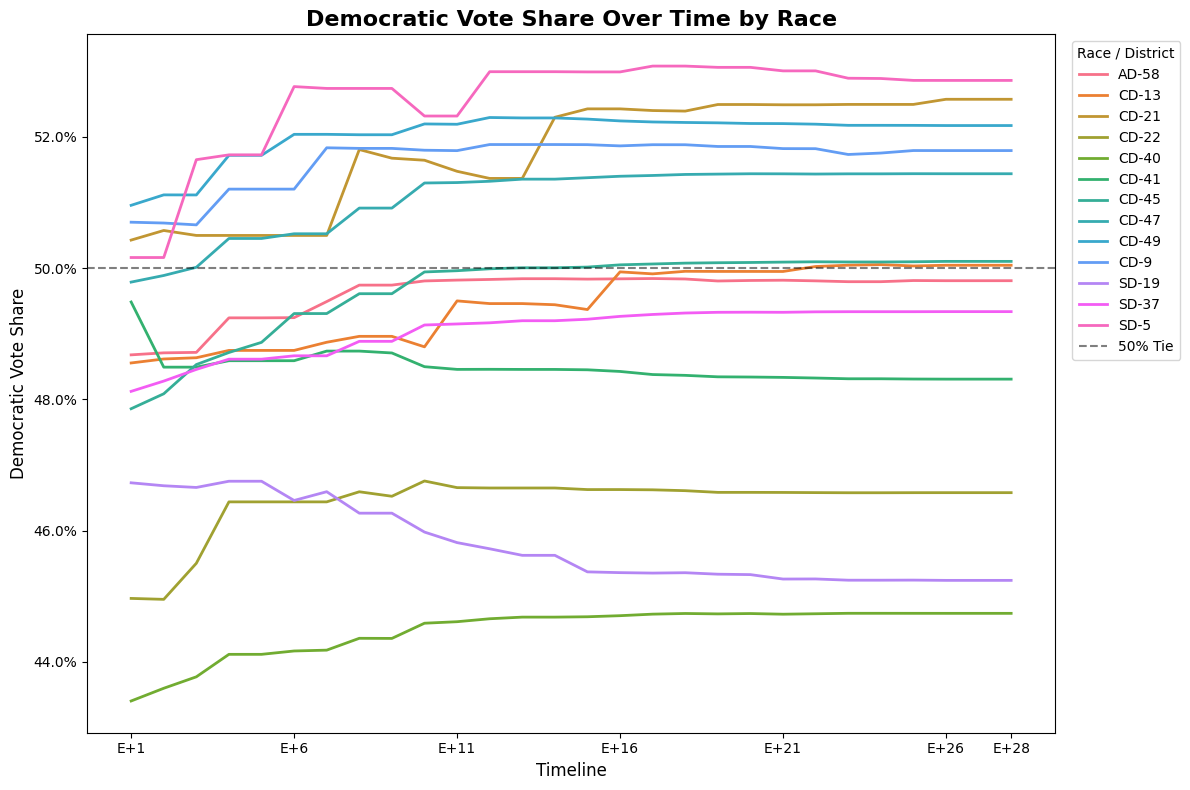

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mtick

# 1. Calculate the Democratic vote share
final_analysis_df['Dem_Share'] = final_analysis_df['D'] / (final_analysis_df['D'] + final_analysis_df['R'])

# 2. Sort by Race and Batch_ID to ensure chronological order
final_analysis_df = final_analysis_df.sort_values(by=['Race', 'Batch_ID'])

# 3. Create the "Days After Election" index
final_analysis_df['Day_Index'] = final_analysis_df.groupby('Race').cumcount() + 1

# 4. Set up the plot
plt.figure(figsize=(12, 8))

# 5. Draw the line plot (Removed marker='o' to drop the dots)
sns.lineplot(
    data=final_analysis_df, 
    x='Day_Index', 
    y='Dem_Share', 
    hue='Race', 
    linewidth=2
)

# 6. Formatting the plot
plt.title('Democratic Vote Share Over Time by Race', fontsize=16, fontweight='bold')
plt.ylabel('Democratic Vote Share', fontsize=12)
plt.xlabel('Timeline', fontsize=12)

# 7. Space out the X-Axis Labels
max_days = final_analysis_df['Day_Index'].max()

# --- CHANGE THIS NUMBER to adjust how spaced out the labels are ---
tick_interval = 5  

# Generate ticks skipping by the interval (e.g., 1, 6, 11...)
spaced_ticks = list(range(1, max_days + 1, tick_interval))

# Force the final day to show up on the axis if it isn't already there
if max_days not in spaced_ticks:
    spaced_ticks.append(max_days)

# Apply the spaced-out ticks and their 'E+' labels
plt.xticks(
    ticks=spaced_ticks, 
    labels=[f'E+{i}' for i in spaced_ticks]
)

# Add a horizontal dashed line at 50%
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='50% Tie')

# Move the legend outside
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Race / District')

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) 

plt.tight_layout()
plt.show()

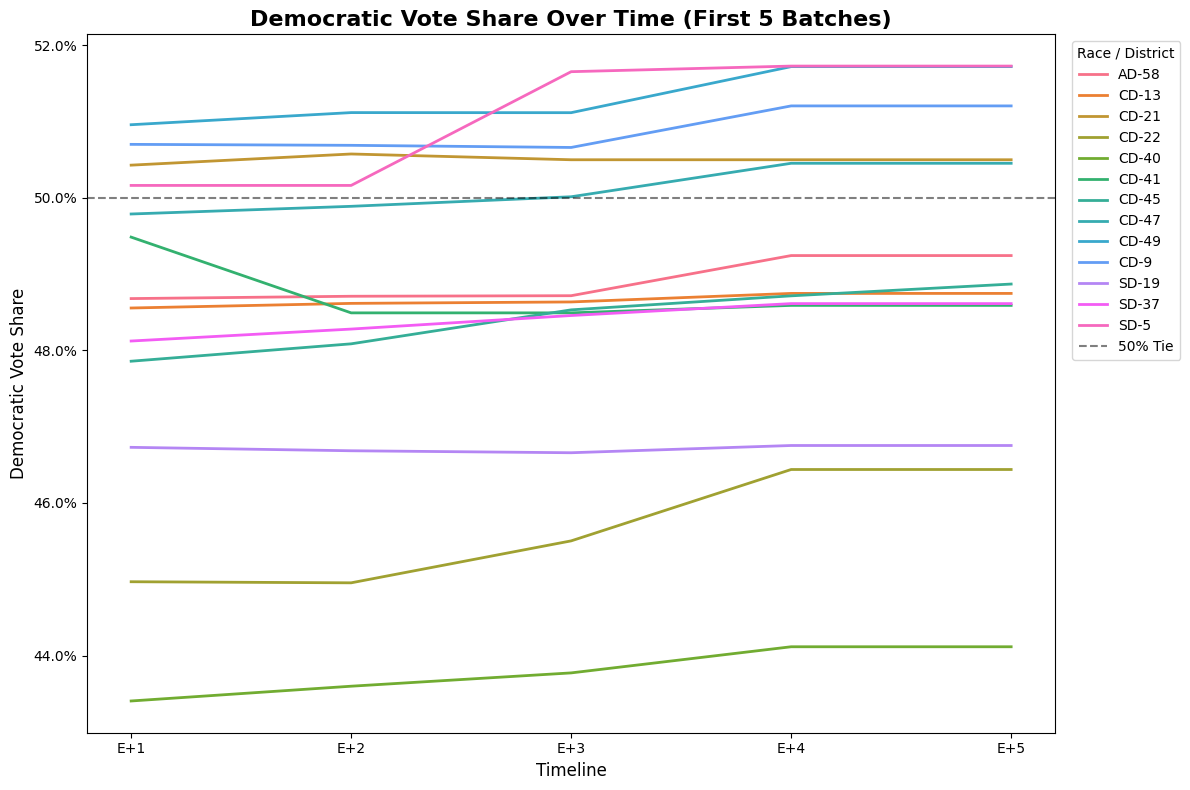

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mtick

# 1. Calculate the Democratic vote share
final_analysis_df['Dem_Share'] = final_analysis_df['D'] / (final_analysis_df['D'] + final_analysis_df['R'])

# 2. Sort by Race and Batch_ID to ensure chronological order
final_analysis_df = final_analysis_df.sort_values(by=['Race', 'Batch_ID'])

# 3. Create the "Days After Election" index
final_analysis_df['Day_Index'] = final_analysis_df.groupby('Race').cumcount() + 1

# 4. FILTER: Keep only the first 5 batches for each race
plot_df = final_analysis_df[final_analysis_df['Day_Index'] <= 5]

# 5. Set up the plot
plt.figure(figsize=(12, 8))

# 6. Draw the line plot using the filtered data
sns.lineplot(
    data=plot_df, 
    x='Day_Index', 
    y='Dem_Share', 
    hue='Race', 
    linewidth=2
)

# 7. Formatting the plot
plt.title('Democratic Vote Share Over Time (First 5 Batches)', fontsize=16, fontweight='bold')
plt.ylabel('Democratic Vote Share', fontsize=12)
plt.xlabel('Timeline', fontsize=12)

# 8. Set X-Axis Labels explicitly for the 5 days
max_days_plotted = plot_df['Day_Index'].max() # Should be 5, but safe to calculate dynamically
plt.xticks(
    ticks=range(1, max_days_plotted + 1), 
    labels=[f'E+{i}' for i in range(1, max_days_plotted + 1)]
)

# Add a horizontal dashed line at 50%
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='50% Tie')

# Move the legend outside
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Race / District')

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) 

plt.tight_layout()
plt.show()

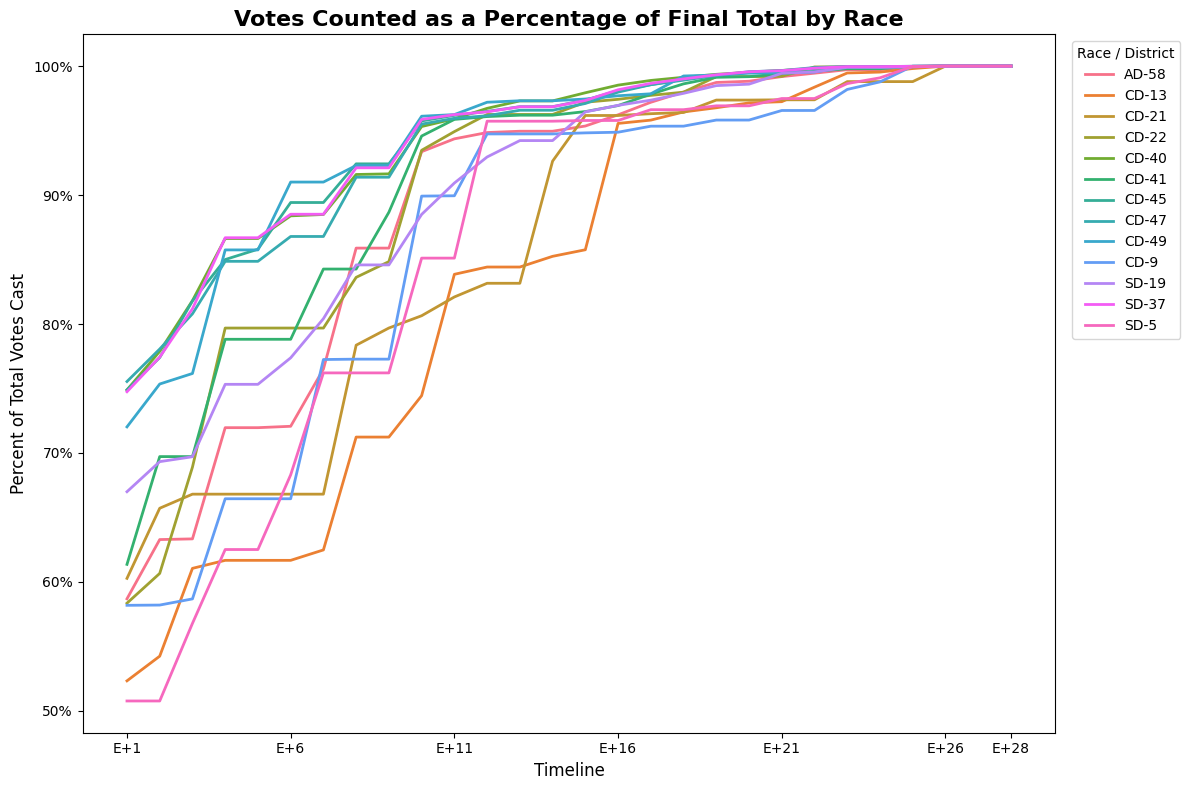

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mtick

# 1. Sort by Race and Batch_ID to ensure chronological order
final_analysis_df = final_analysis_df.sort_values(by=['Race', 'Batch_ID'])

# 2. Find the "whole" (the final/maximum total votes) for each race.
# .transform('max') takes the max value for the group and broadcasts it to every row for that race.
final_analysis_df['Final_Total_Votes'] = final_analysis_df.groupby('Race')['Total Votes Cast'].transform('max')

# 3. Calculate the percent of the whole (current batch votes / final total votes)
final_analysis_df['Percent_of_Final'] = final_analysis_df['Total Votes Cast'] / final_analysis_df['Final_Total_Votes']

# 4. Create the "Days After Election" index
final_analysis_df['Day_Index'] = final_analysis_df.groupby('Race').cumcount() + 1

# 5. Set up the plot
plt.figure(figsize=(12, 8))

# 6. Draw the line plot
sns.lineplot(
    data=final_analysis_df, 
    x='Day_Index', 
    y='Percent_of_Final', 
    hue='Race', 
    linewidth=2
)

# 7. Formatting the plot titles and labels
plt.title('Votes Counted as a Percentage of Final Total by Race', fontsize=16, fontweight='bold')
plt.ylabel('Percent of Total Votes Cast', fontsize=12)
plt.xlabel('Timeline', fontsize=12)

# 8. Space out the X-Axis Labels (e.g., every 5 days)
max_days = final_analysis_df['Day_Index'].max()
tick_interval = 5  

spaced_ticks = list(range(1, max_days + 1, tick_interval))
if max_days not in spaced_ticks:
    spaced_ticks.append(max_days)

plt.xticks(
    ticks=spaced_ticks, 
    labels=[f'E+{i}' for i in spaced_ticks]
)

# 9. Format y-axis as percentages
# 1.0 tells the formatter that our data is on a 0.0 to 1.0 scale
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 10. Move the legend outside the plot area
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Race / District')

plt.tight_layout()
plt.show()